# Zdolność produkcyjna zakładu a przepustowość: dwuwymiarowa analiza portfela za pomocą PROC SGPLOT

## Podsumowanie wykonawcze

Portfel produkcyjny wytwórstwa dyskretnego ma dwie liczby, które liczą się jednocześnie dla każdej linii produktu: **ile zdolności produkcyjnej maszyn zużywa** i **ile dobrego wyjścia faktycznie dostarcza**. Jednowymiarowy wykres słupkowy może pokazać tylko jedną z nich. Ten notatnik wizualizuje obie naraz za pomocą `PROC SGPLOT`, wykorzystując **wykres bąbelkowy** jako widok główny — każda linia jest pozycjonowana wg zdolności produkcyjnej (x) i przepustowości (y), a wielkość bąbla koduje jej wskaźnik produktywności (jednostki na godzinę maszynową). Linie leżące nisko i po prawej (dużo zdolności, mało wyjścia) są pochłaniaczami zdolności produkcyjnej; linie leżące wysoko i po lewej z dużym bąblem są liniami o wysokiej wydajności. Widok słupków grupowanych następnie rozkłada przepustowość wg zakładu, a ranking produktywności potwierdza tę różnicę.

Na podstawie rzeczywistego wykonanego wyjścia (osiem linii produktu w trzech zakładach, 100 przebiegów na poziomie zmiany zagregowanych do 24 komórek linia-zakład), analiza stwierdza, że **Odlewanie** jest najwyraźniejszym pochłaniaczem zdolności produkcyjnej w portfelu (14,3 dobrej jednostki na godzinę maszynową — pochłania 10,1% łącznej zdolności, a dostarcza jedynie 3,2% dobrych jednostek), podczas gdy **Pakowanie** jest wyróżniającą się linią o wysokiej wydajności (119,2 jednostki na godzinę — 9,1% zdolności zwraca 23,8% wyjścia). Wśród zakładów **Stuttgart** działa najgoręcej przy 49,9 jednostki/godz., a **Monterrey** najchłodniej przy 41,6.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Syntetyczne przebiegi produkcyjne na poziomie zmiany dla 8 linii produktu, 3 zakładów i 3 zmian — zaplanowane godziny maszynowe, godziny pracy, przestoje, jednostki brutto/braków/dobre (ograniczone do 100 obserwacji w trybie bez licencji) | 100 |
| WORK.LINE_CAPACITY | Zagregowane zestawienie na poziomie linii produktu i zakładu: łączne godziny zdolności produkcyjnej (x), wyprodukowane dobre jednostki (y) i % wydajności akceptowanych jednostek | 24 |

*Wszystkie dane są syntetyczne i generowane wewnątrz notatnika z ustalonym ziarnem — bez zewnętrznych plików, bez sieci.*

# Analiza zdolności produkcyjnej zakładu a przepustowości

**Dziedzina:** Wytwórstwo dyskretne — operacje / inżynieria przemysłowa

**Procedura:** `PROC SGPLOT` (ODS Statistical Graphics)

Konwencjonalny wykres słupkowy pokazuje jedną odpowiedź na kategorię. Aby porównać portfel produkcyjny na **dwóch** wymiarach liczbowych naraz — *ile zdolności produkcyjnej zużywa każda linia produktu* w porównaniu z *ile wyjścia faktycznie dostarcza* — potrzebujemy wykresu, który umieszcza obie wielkości na tym samym płótnie. Instrukcja `BUBBLE` w `PROC SGPLOT` robi dokładnie to: pozycjonuje każdą linię wg zdolności produkcyjnej (x) i dobrych jednostek (y), a trzecia miara, wskaźnik produktywności, steruje wielkością bąbla. Linia leżąca daleko po prawej, ale nisko, jest pochłaniaczem zdolności produkcyjnej; linia leżąca wysoko i po lewej z grubym bąblem jest linią o wysokiej wydajności wartą ochrony. Ten notatnik buduje realistyczny syntetyczny zbiór danych produkcyjnych i prowadzi SGPLOT przez wykres bąbelkowy, wykres słupkowy grupowany wg zakładu, analizę pojedynczego zakładu oraz porównanie zakładów obok siebie (słupki grupowane).

> **Uwaga o PROC GAREABAR.** Klasycznym sposobem SAS/GRAPH na zakodowanie dwóch wymiarów na *słupek* jest `PROC GAREABAR` (wykres area-bar dostępny wyłącznie przez ActiveX, gdzie szerokość słupka koduje jedną zmienną, a wysokość drugą). GAREABAR **nie jest jeszcze zaimplementowany w tej wersji Jenner** — luka jest śledzona przez zbankowany test `tests/400996_nb_gareabar_unimplemented`. Ten notatnik osiąga ten sam cel analityczny za pomocą w pełni wspieranego `PROC SGPLOT`, którego widoki bąbelkowy i słupkowy grupowany przekazują identyczną historię zdolność-produkcyjna-a-przepustowość.

## 1. Wygenerowanie syntetycznych danych produkcyjnych

Symulujemy sześć tygodni przebiegów produkcyjnych na poziomie zmiany dla sieci trzech zakładów wytwórstwa dyskretnego. Każda linia produktu ma bazowy czas cyklu i wskaźnik braków; przepustowość jest sterowana zaplanowanymi godzinami maszynowymi, efektywnością specyficzną dla linii i losowymi przestojami. `call streaminit` ustala ziarno, dzięki czemu notatnik jest w pełni powtarzalny — bez zewnętrznych plików, bez sieci.

In [1]:
/* --------------------------------------------------------
   Syntetyczne zmianowe przebiegi produkcyjne
   8 linii produktu x 3 zakłady x 3 zmiany x ~10 dni
   zmienna szerokości = zaplanowane godziny maszynowe (zdolność)
   odpowiedź            = wyprodukowane dobre jednostki (przepustowość)
   -------------------------------------------------------- */
DANE work.production_runs;
    CALL streaminit(20260531);
    DŁUGOŚĆ product_line $24 plant $12 shift $14;

    /* nominalne jednostki produkowane na godzinę maszynową, wg linii */
    TABLICA line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* bazowy udział braków wg linii */
    TABLICA line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    TABLICA plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* mnożnik efektywności zakładu */
    TABLICA plant_eff[3] _temporary_ (1.00 0.92 1.08);
    /* mnożnik efektywności zmiany */
    TABLICA shift_eff[3] _temporary_ (1.00 0.95 0.88);

    POWTÓRZ day = 1 TO 10;
        POWTÓRZ li = 1 TO 8;
            POWTÓRZ pi = 1 TO 3;
                POWTÓRZ si = 1 TO 3;
                    /* Nazwa linii produktu - przypisanie wprost zamiast
                       tablicy _temporary_, aby uniknąć obcinania
                       nie-ASCII łańcuchów przez silnik */
                    JEŚLI      li = 1 WTEDY product_line = 'Tłoczenie';
                    PRZECIWNIE JEŚLI li = 2 WTEDY product_line = 'Spawanie';
                    PRZECIWNIE JEŚLI li = 3 WTEDY product_line = 'Skrawanie';
                    PRZECIWNIE JEŚLI li = 4 WTEDY product_line = 'Odlewanie';
                    PRZECIWNIE JEŚLI li = 5 WTEDY product_line = 'Wtrysk';
                    PRZECIWNIE JEŚLI li = 6 WTEDY product_line = 'Montaż';
                    PRZECIWNIE JEŚLI li = 7 WTEDY product_line = 'Wykańczanie';
                    PRZECIWNIE                 product_line = 'Pakowanie';

                    plant        = plant_names[pi];

                    /* Nazwa zmiany - przypisanie wprost, ten sam powód */
                    JEŚLI      si = 1 WTEDY shift = 'Dzień';
                    PRZECIWNIE JEŚLI si = 2 WTEDY shift = 'Popołudnie';
                    PRZECIWNIE                shift = 'Noc';

                    /* zaplanowane godziny maszynowe dla zmiany */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* nieplanowany przestój zjada zdolność produkcyjną */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* efektywne tempo przepustowości z szumem */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    WYJŚCIE;
                KONIEC;
            KONIEC;
        KONIEC;
    KONIEC;
    ZACHOWAJ run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.production_runs(obs=8) noobs;
    ETYKIETA product_line="Linia produktu" plant="Zakład" shift="Zmiana"
          sched_hours="Zapl. godz. masz." run_hours="Godz. pracy"
          downtime_hours="Godz. przestoju" gross_units="Jedn. brutto"
          scrap_units="Jedn. braków" good_units="Dobre jedn.";
    TYTUŁ 'Próbka syntetycznych zmianowych przebiegów produkcyjnych';
WYKONAJ;
TYTUŁ;

                                Próbka syntetycznych zmianowych przebiegów produkcyjnych                                

 run_date  Linia produktu     Zakład       Zmiana  Zapl. godz. masz.  Godz. pracy  Godz. przestoju  Jedn. brutto   Jedn. braków  Dobre jedn.
05JAN2026  Tłoczenie       Detroit    Dzień                      7.8          6.7              1.1           306             14          292
05JAN2026  Tłoczenie       Detroit    Popołudnie                 6.8          6.5              0.3           259             12          247
05JAN2026  Tłoczenie       Detroit    Noc                          8          7.6              0.4           269             11          258
05JAN2026  Tłoczenie       Monterrey  Dzień                      7.9          6.8              1.1           283             12          271
05JAN2026  Tłoczenie       Monterrey  Popołudnie                 7.5          6.9              0.6           254              9          245
05JAN2026  Tłoczenie       Monte


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.22 seconds
  cpu   0.22 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Agregacja do poziomu linia i zakład

Wykresy porównują jeden punkt na kategorię, więc zwijamy szczegóły na poziomie zmiany do zestawienia na poziomie linii produktu i zakładu. `total_capacity` (suma zaplanowanych godzin maszynowych) staje się wymiarem **x**, `good_units` (suma zaakceptowanego wyjścia) wymiarem **y**, a `units_per_hr` (dobre jednostki ÷ godziny zdolności) wskaźnikiem produktywności, który określi wielkość bąbli. Zachowujemy `plant`, aby mogła później służyć jako zmienna grupująca. Budujemy też zbiorcze zestawienie na poziomie linii (dla wszystkich zakładów) na potrzeby wykresu bąbelkowego portfela.

In [2]:
/* --------------------------------------------------------
   Agregacja do poziomu linia_produktu x zakład
   total_capacity -> x (godziny zdolności produkcyjnej)
   good_units     -> y (przepustowość)
   units_per_hr   -> wielkość bąbla (produktywność)
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.production_runs NOPRINT NWAY;
    KLASA product_line plant;
    ZMIENNA sched_hours good_units scrap_units;
    WYJŚCIE out=work.line_capacity(USUŃ=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
WYKONAJ;

DANE work.line_capacity;
    USTAW work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
WYKONAJ;

PROCEDURA SORTUJ DANE=work.line_capacity;
    WEDŁUG product_line plant;
WYKONAJ;

/* Zbiorcze zestawienie na poziomie linii (dla wszystkich 3 zakładów) dla widoku portfela */
PROCEDURA ŚREDNIE DANE=work.line_capacity NOPRINT NWAY;
    KLASA product_line;
    ZMIENNA total_capacity good_units;
    WYJŚCIE out=work.line_total(USUŃ=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
WYKONAJ;

DANE work.line_total;
    USTAW work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
WYKONAJ;

PROCEDURA SORTUJ DANE=work.line_total;
    WEDŁUG units_per_hr;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.line_total noobs;
    ZMIENNA product_line total_capacity good_units units_per_hr;
    ETYKIETA product_line="Linia produktu" total_capacity="Godziny zdolności"
          good_units="Dobre jednostki" units_per_hr="Jedn./godz.";
    TYTUŁ 'Linie portfela uszeregowane wg produktywności (dobre jednostki na godzinę maszynową)';
WYKONAJ;
TYTUŁ;

                  Linie portfela uszeregowane wg produktywności (dobre jednostki na godzinę maszynową)                  

Linia produktu   Godziny zdolności  Dobre jednostki  Jedn./godz.
Odlewanie                     73.4             1050         14.3
Spawanie                     130.8             3038         23.2
Skrawanie                    128.9             3762         29.2
Tłoczenie                    130.7             4713         36.1
Wtrysk                        66.2             3430         51.8
Montaż                        67.3             4289         63.7
Wykańczanie                   64.6             4927         76.3
Pakowanie                     65.9             7855        119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Otwarcie miejsca docelowego ODS Graphics

`PROC SGPLOT` renderuje poprzez ODS Statistical Graphics. Otwieramy miejsce docelowe `ODS HTML`, aby każdy wykres był emitowany jako obraz, i włączamy `ODS GRAPHICS ON`. Nie jest wymagany żaden specjalny sterownik urządzenia — SGPLOT jest niezależny od urządzenia, w przeciwieństwie do procedur SAS/GRAPH dostępnych wyłącznie przez ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Wykres bąbelkowy portfela — zdolność produkcyjna a przepustowość

Widok główny: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Każda linia produktu to jeden bąbel, pozycjonowany wg łącznych godzin zdolności produkcyjnej (x) i łącznych dobrych jednostek (y), przy czym powierzchnia bąbla jest skalowana wg jego wskaźnika produktywności. `DATALABEL=` wypisuje nazwę linii obok każdego bąbla. To jest dwuwymiarowe porównanie, którego potrzebuje kierownik zakładu — pochłaniacze zdolności produkcyjnej opadają w **dolny prawy róg** (dużo godzin, mało wyjścia, mały bąbel); linie o wysokiej wydajności wznoszą się w **górny lewy róg** (mało godzin, dużo wyjścia, duży bąbel).

                               Portfel produkcyjny - zdolność produkcyjna a przepustowość                               
             x = zaplanowane godziny maszynowe; y = dobre jednostki; wielkość bąbla = jednostki na godzinę              


Dolny prawy róg = pochłaniacz zdolności produkcyjnej; górny lewy z dużym bąblem = linia o wysokiej wydajności.



NOTE: Option TITLE changed to Portfel produkcyjny - zdolność produkcyjna a przepustowość.
NOTE: Option TITLE2 changed to x = zaplanowane godziny maszynowe; y = dobre jednostki; wielkość bąbla = jednostki na godzinę.
NOTE: Option FOOTNOTE changed to Dolny prawy róg = pochłaniacz zdolności produkcyjnej; górny lewy z dużym bąblem = linia o wysokiej wydajności..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


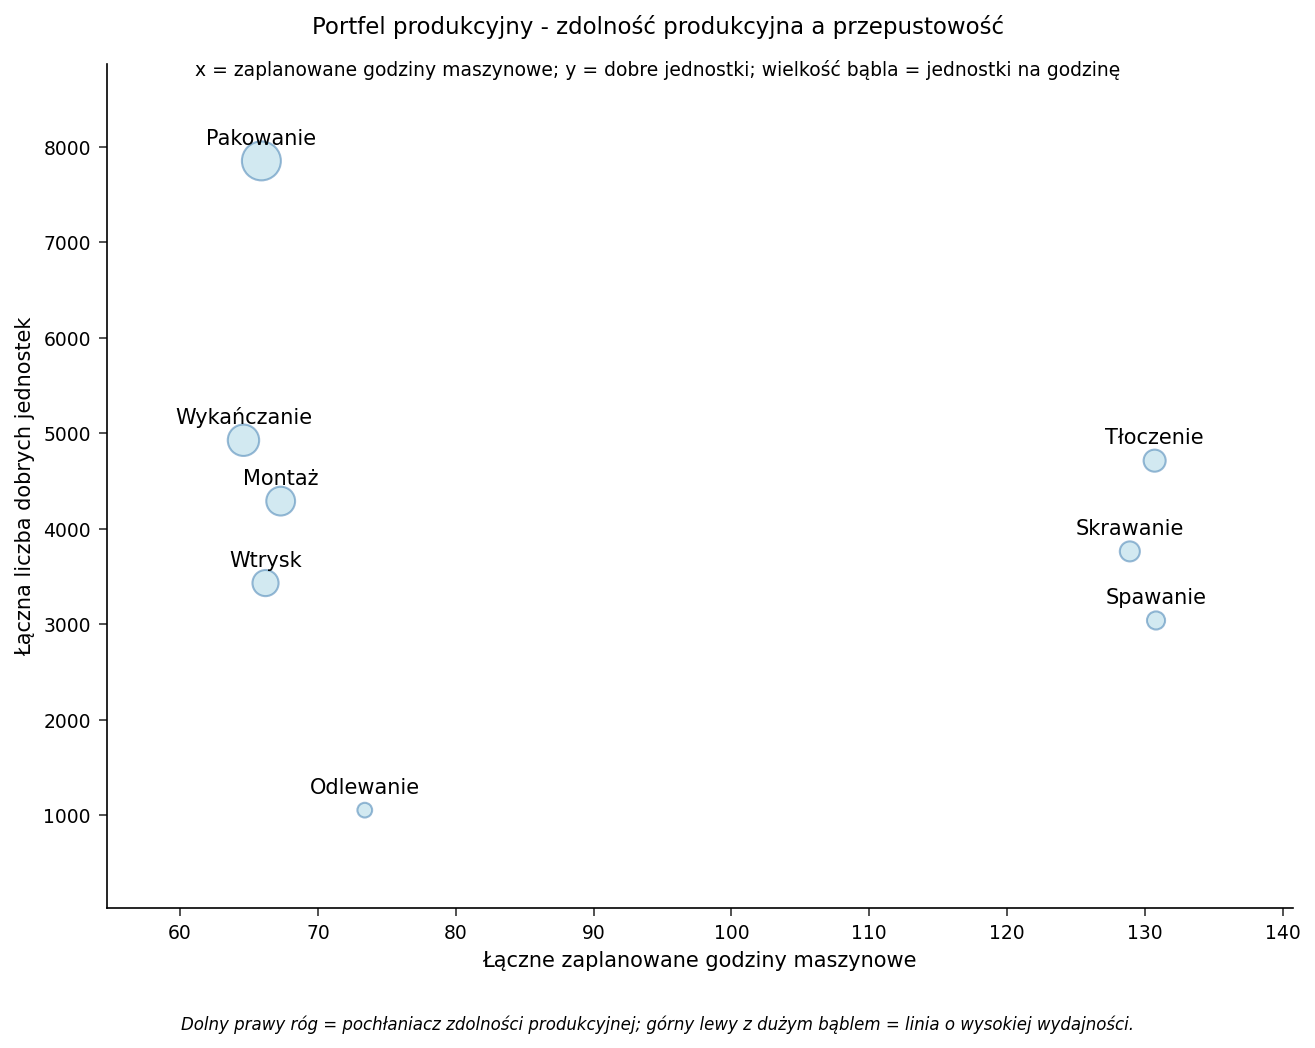

In [4]:
TYTUŁ 'Portfel produkcyjny - zdolność produkcyjna a przepustowość';
title2 'x = zaplanowane godziny maszynowe; y = dobre jednostki; wielkość bąbla = jednostki na godzinę';
footnote JUSTIFY=LEFT
    'Dolny prawy róg = pochłaniacz zdolności produkcyjnej; górny lewy z dużym bąblem = linia o wysokiej wydajności.';

PROCEDURA SGPLOT DANE=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ETYKIETA='Łączne zaplanowane godziny maszynowe';
    YAXIS ETYKIETA='Łączna liczba dobrych jednostek';
WYKONAJ;

TYTUŁ; title2; footnote;

## 5. Przepustowość wg linii, rozłożona wg zakładu

Aby zobaczyć, jak wyjście każdej linii rozkłada się na trzy zakłady, wykres `VBAR product_line / response=good_units group=plant` układa wkłady zakładów wewnątrz każdego słupka. To jest widok segmentacyjny: pokazuje zarówno całkowitą wysokość (dobre jednostki na linię), jak i mieszankę zakładów wewnątrz każdego słupka, dzięki czemu można dostrzec linie, w których jeden zakład dominuje wyjście.

                                 Dobre jednostki wg linii produktu, ułożone wg zakładu                                  
                          Wysokość słupka = łączne dobre jednostki; segmenty = udział zakładu                           




NOTE: Option TITLE changed to Dobre jednostki wg linii produktu, ułożone wg zakładu.
NOTE: Option TITLE2 changed to Wysokość słupka = łączne dobre jednostki; segmenty = udział zakładu.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


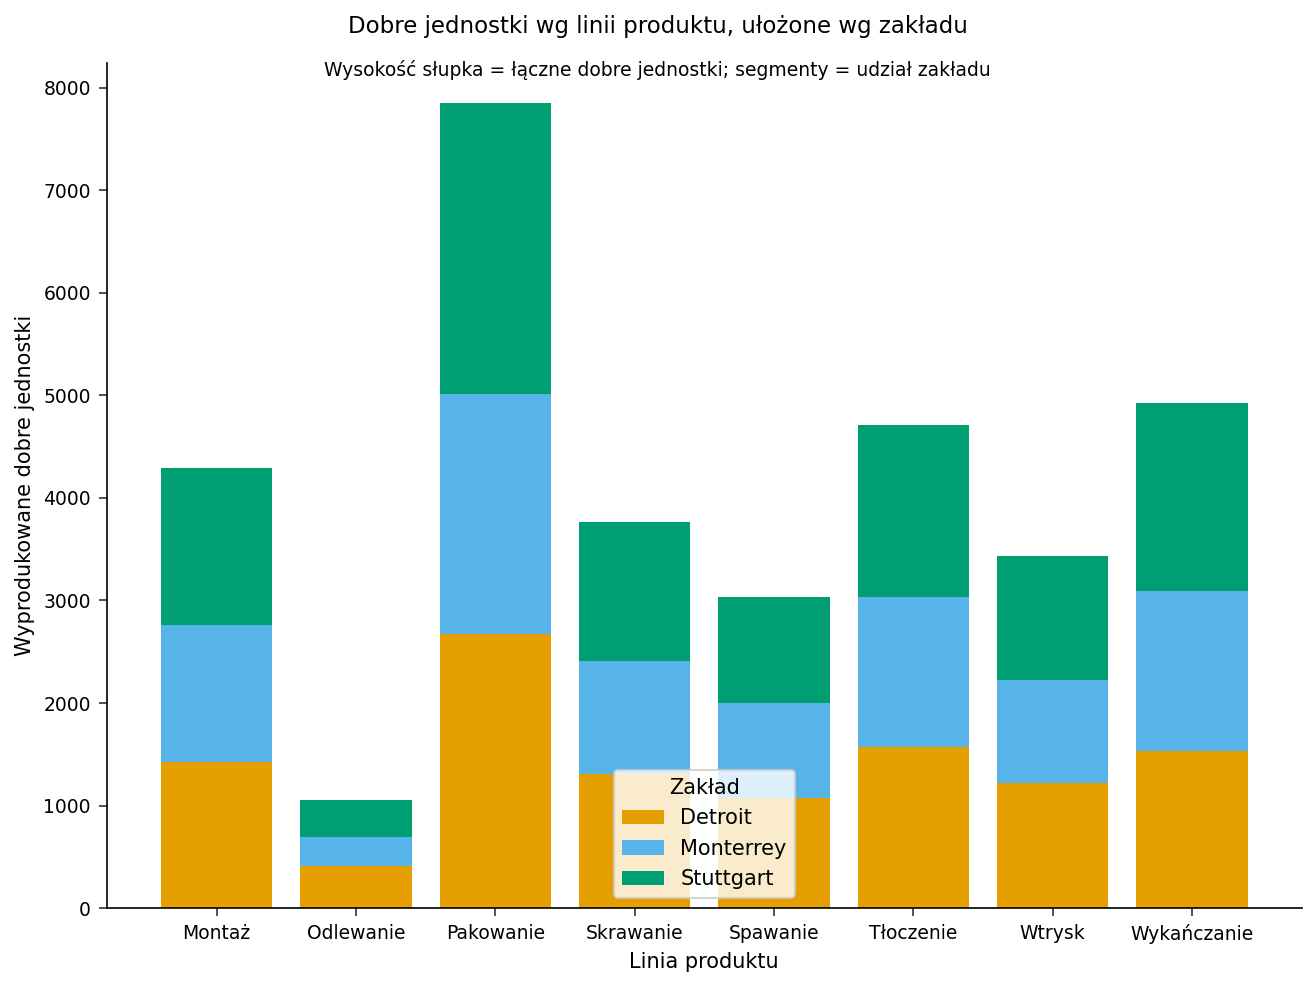

In [5]:
TYTUŁ 'Dobre jednostki wg linii produktu, ułożone wg zakładu';
title2 'Wysokość słupka = łączne dobre jednostki; segmenty = udział zakładu';

PROCEDURA SGPLOT DANE=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ETYKIETA='Linia produktu' fitpolicy=ROTATE;
    YAXIS ETYKIETA='Wyprodukowane dobre jednostki';
    keylegend / TYTUŁ='Zakład' position=bottom;
WYKONAJ;

TYTUŁ; title2;

## 6. Analiza produktywności pojedynczego zakładu (WHERE)

Poziome słupki (`HBAR`) pasują do długich etykiet linii produktu. Klauzula `WHERE` zawęża dane do zakładu Stuttgart, a słupki są rysowane dla `units_per_hr`, więc wykres szereguje linie zakładu Stuttgart wg produktywności. Ponieważ dane wejściowe są posortowane rosnąco wg wskaźnika, najmniej produktywna linia znajduje się na dole, a najbardziej produktywna na górze.

                                Zakład Stuttgart - linie uszeregowane wg produktywności                                 


Długość słupka = dobre jednostki na godzinę maszynową (analiza jednego zakładu).



NOTE: Option TITLE changed to Zakład Stuttgart - linie uszeregowane wg produktywności.
NOTE: Option FOOTNOTE changed to Długość słupka = dobre jednostki na godzinę maszynową (analiza jednego zakładu)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


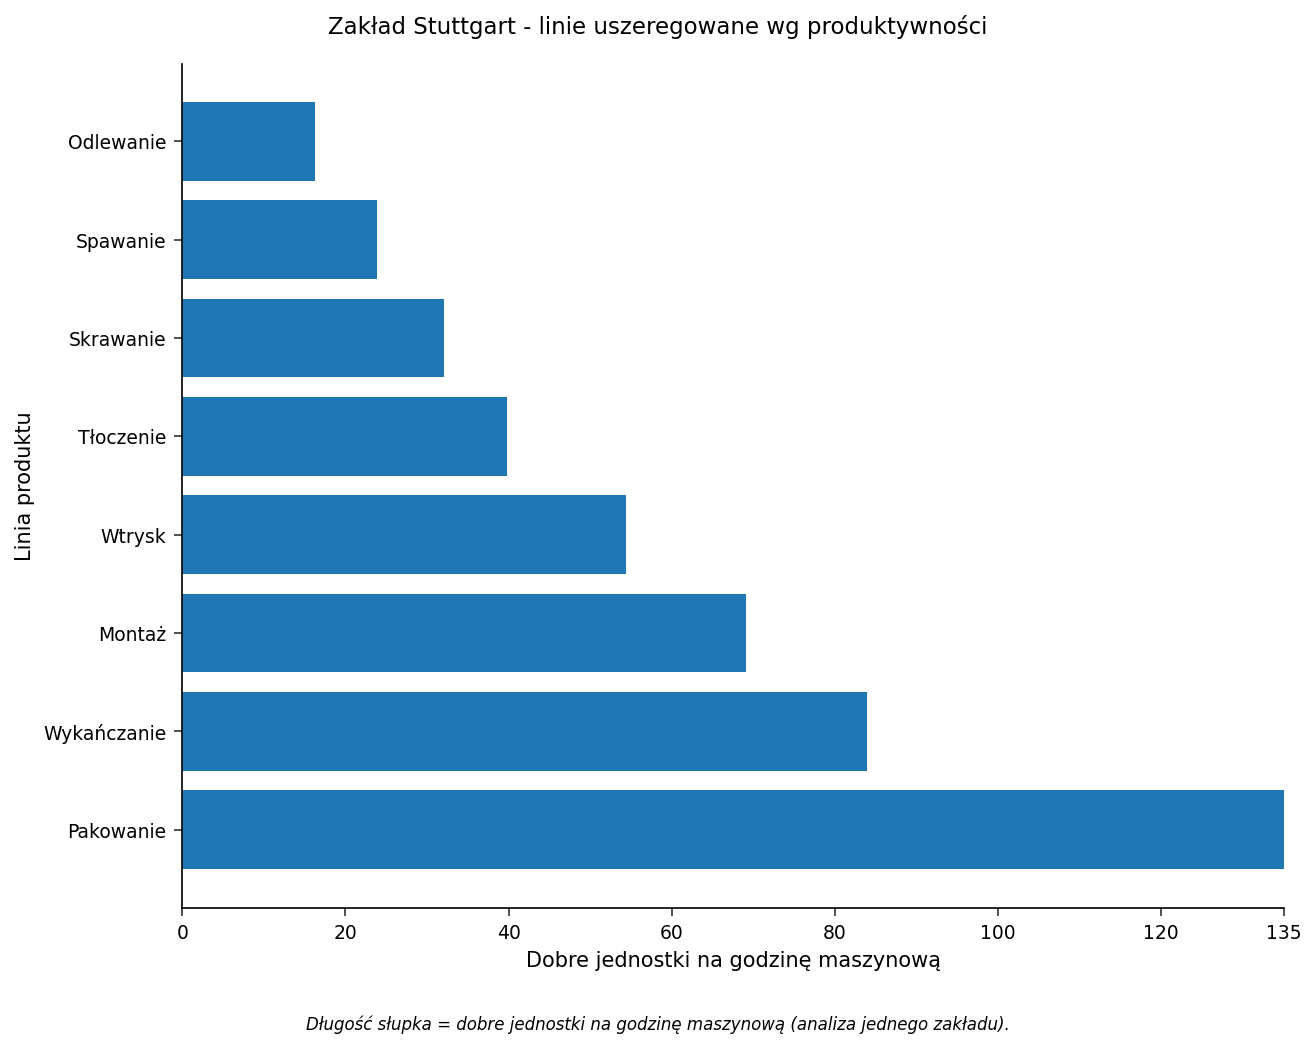

In [6]:
TYTUŁ 'Zakład Stuttgart - linie uszeregowane wg produktywności';
footnote JUSTIFY=LEFT 'Długość słupka = dobre jednostki na godzinę maszynową (analiza jednego zakładu).';

PROCEDURA SGPLOT DANE=work.line_capacity;
    GDZIE plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ETYKIETA='Dobre jednostki na godzinę maszynową';
    YAXIS ETYKIETA='Linia produktu';
WYKONAJ;

TYTUŁ; footnote;

## 7. Porównanie zakładów obok siebie (słupki grupowane)

Aby porównać trzy zakłady linia po linii, wykres słupkowy grupowany (`GROUPDISPLAY=CLUSTER`) rysuje Detroit, Monterrey i Stuttgart jako sąsiadujące słupki w obrębie każdej linii produktu. To jest widok porównywalny jak-do-jak dla zakładów: dla dowolnej linii można odczytać, który zakład wyprodukował najwięcej dobrych jednostek, co czyni różnice efektywności zakładów (Stuttgart najwyższa, Monterrey najniższa) bezpośrednio widocznymi.

                                    Dobre jednostki wg linii i zakładu - obok siebie                                    
                        Słupki grupowane: jeden słupek na zakład w obrębie każdej linii produktu                        




NOTE: Option TITLE changed to Dobre jednostki wg linii i zakładu - obok siebie.
NOTE: Option TITLE2 changed to Słupki grupowane: jeden słupek na zakład w obrębie każdej linii produktu.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


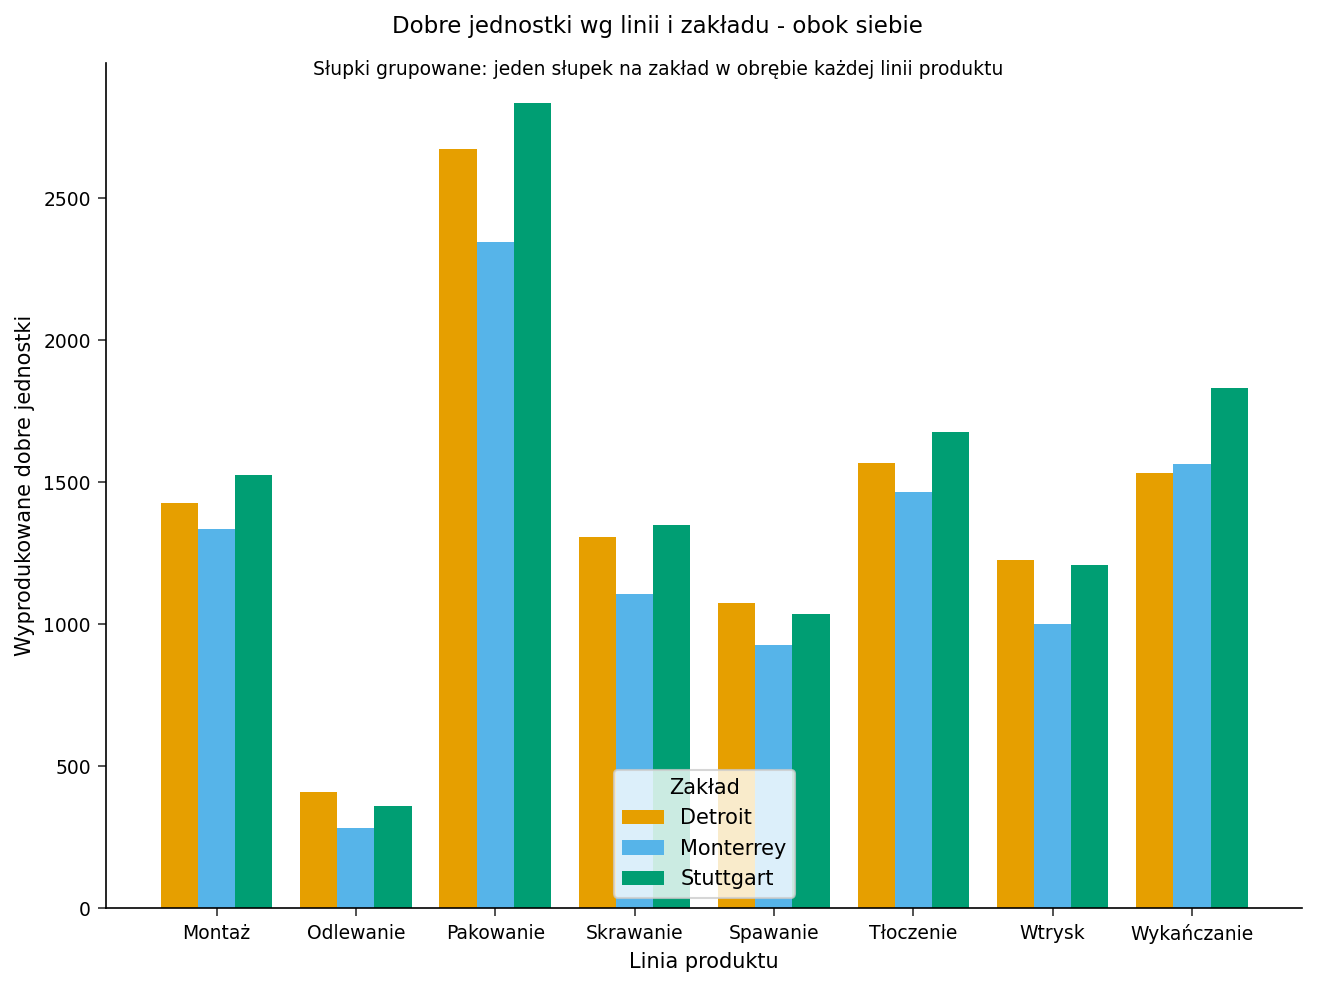

In [7]:
TYTUŁ 'Dobre jednostki wg linii i zakładu - obok siebie';
title2 'Słupki grupowane: jeden słupek na zakład w obrębie każdej linii produktu';

PROCEDURA SGPLOT DANE=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ETYKIETA='Linia produktu' fitpolicy=ROTATE;
    YAXIS ETYKIETA='Wyprodukowane dobre jednostki';
    keylegend / TYTUŁ='Zakład' position=bottom;
WYKONAJ;

TYTUŁ; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interpretacja

Wykreślenie zdolności produkcyjnej i przepustowości na tych samych osiach ujawnia zależność, którą jednowymiarowy wykres słupkowy by ukrył. **Odlewanie** jest najwyraźniejszym pochłaniaczem zdolności produkcyjnej w portfelu: w rankingu produktywności znajduje się na dole z wynikiem **14,3 dobrej jednostki na godzinę maszynową**, a na wykresie bąbelkowym opada w dolny lewy róg jako mały bąbel — pochłania **10,1%** łącznych zaplanowanych godzin, a zwraca jedynie **3,2%** dobrych jednostek (ma też najniższą wydajność, ~91%, z powodu wysokiego udziału braków). Jest głównym kandydatem do kaizen skracania czasu cyklu i redukcji braków. Na przeciwnym biegunie **Pakowanie** jest wyróżniającą się linią o wysokiej wydajności przy **119,2 jednostki na godzinę maszynową** — duży bąbel wysoko na osi przepustowości, który zamienia **9,1%** zdolności w **23,8%** wszystkich dobrych jednostek; ochrona jego czasu pracy daje nieproporcjonalnie duże wyjście. **Wykańczanie** (76,3 jedn./godz.) i **Montaż** (63,7) podążają za tym samym wzorcem wysokiej wydajności.

Wzorzec jest systematyczny: cztery wolne, żarłoczne pod względem zdolności produkcyjnej linie wcześniejszego etapu — Odlewanie, Spawanie (23,2 jedn./godz.), Skrawanie (29,2) i Tłoczenie (36,1) — razem zużywają w przybliżeniu **64%** zaplanowanych godzin, ale dostarczają jedynie ok. **38%** dobrych jednostek, podczas gdy cztery szybkie linie późniejszego etapu dostarczają nadwyżkowo względem zużywanych godzin. Widok ułożony wg zakładu i słupki grupowane obok siebie pokazują wymiar zakładu stojący za tym: **Stuttgart** działa najgoręcej przy **49,9 dobrej jednostki na godzinę maszynową**, **Detroit** jest pośrodku przy **44,9**, a **Monterrey** pozostaje w tyle przy **41,6** — spójnie z wyżej zamodelowanym przestojem Monterrey. Operacyjnie wskazuje to na przesunięcie zaplanowanych godzin w kierunku linii późniejszego etapu o wysokiej wydajności oraz porównanie przestojów Monterrey z praktykami Stuttgart.

*Wyłącznie dane syntetyczne — liczby ilustrują dwuwymiarową wizualizację zdolność-produkcyjna-a-przepustowość za pomocą PROC SGPLOT, a nie rzeczywistą wydajność zakładu.*